In [1]:
!pip install --upgrade seaborn

In [2]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import precision-recall metrics from scikit-learn.
from sklearn.metrics import precision_recall_curve, average_precision_score

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
#    These 8 colors are maximally distinguishable for all color vision types.
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION & SETTINGS
#    Auto-picks the best sans-serif font already on your machine.
#    Minimum size is 18pt; titles and labels are larger.
#
#    >>> To see ALL fonts available on your system, run in a cell:
#    >>>     from plot_template import list_fonts
#    >>>     list_fonts()
#
#    >>> To override the auto-picked font, set FONT_FAMILY before importing:
#    >>>     import plot_template
#    >>>     plot_template.FONT_FAMILY = "Verdana"
#    >>>     plot_template.apply_style()   # re-apply with your choice
# =============================================================================

def list_fonts(filter_text=None):
    """
    Print every font matplotlib can see on your system.
    Pass a string to filter, e.g. list_fonts("arial") or list_fonts("sans").
    """
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  • {n}")
    return names

# Preferred fonts in priority order (all clean presentation sans-serifs)
_FONT_PREFERENCES = [
    "Arial",
    "Helvetica",
    "Helvetica Neue",
    "Calibri",
    "Verdana",
    "Segoe UI",
    "Liberation Sans",
    "DejaVu Sans",
]

def _find_best_font():
    """Return the first preferred font that is actually installed."""
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    # Nothing from the preferred list — just grab any sans-serif we can find
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    # True last resort
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30      # figure / axes title
FONT_SIZE_LABEL   = 40      # axis labels
FONT_SIZE_TICK    = 24      # tick labels
FONT_SIZE_LEGEND  = 35      # legend text
FONT_SIZE_ANNOT   = 24      # annotations / text on plot

# =============================================================================
# 3. APPLY GLOBAL STYLE (matplotlib + seaborn)
#    Called automatically on import. Call again after changing FONT_FAMILY.
# =============================================================================

def apply_style():
    """Apply (or re-apply) the full presentation style using current settings."""
    mpl.rcParams.update({
        # --- Font -----------------------------------------------------------
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,       # base / fallback size

        # --- Axes -----------------------------------------------------------
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          False,
        "axes.axisbelow":     True,                   # grid behind data

        # --- Ticks ----------------------------------------------------------
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",

        # --- Grid -----------------------------------------------------------
        # "grid.color":         "#dbdbdb",
        # "grid.linewidth":     0.8,
        # "grid.alpha":         1.0,

        # --- Legend ----------------------------------------------------------
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",

        # --- Lines & markers ------------------------------------------------
        "lines.linewidth":    2.5,
        "lines.markersize":   10,

        # --- Figure ---------------------------------------------------------
        "figure.figsize":     (17, 5),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",

        # --- Saving ---------------------------------------------------------
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })

    sns.set_theme(
        style="white",
        font=FONT_FAMILY,
        font_scale=1.4,
        rc=mpl.rcParams,
    )
    sns.set_palette(CB_PALETTE)

    # Re-assert settings that seaborn's set_theme can override
    mpl.rcParams.update({
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelweight":   "bold",
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        # "grid.color":         "#dbdbdb",
        # "grid.alpha":         1.0,
    })

# Auto-apply on import
apply_style()

# =============================================================================
# 5. HELPER FUNCTIONS
# =============================================================================

def add_legend(ax=None, title=None, **kwargs):
    """
    Add a styled legend to the current or specified axes.
    Merges template defaults with any overrides you pass in.
    """
    ax = ax or plt.gca()
    defaults = dict(
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        framealpha=0.9,
        edgecolor="#999999",
        loc="best",
    )
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend


def get_colors(n=None):
    """
    Return the colorblind-friendly palette (or the first n colors).
    Useful when you need explicit color assignments.

    Usage:
        colors = get_colors(3)
        ax.bar(x, y1, color=colors[0], label="Group A")
        ax.bar(x, y2, color=colors[1], label="Group B")
    """
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]


def finalize(fig=None, tight=True):
    """
    Call at the end of every plot cell to tighten layout.
    """
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()


Font: Liberation Sans


In [4]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/xgboost_20260423_105614.csv", dtype=str, low_memory=False)
df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c], errors='ignore')

df["true_label"] = pd.to_numeric(df["true_label"], errors="coerce")
df["predicted_score"] = pd.to_numeric(df["predicted_score"], errors="coerce")
# Convert the true label column to integers.
df["true_label"] = df["true_label"].astype(int)

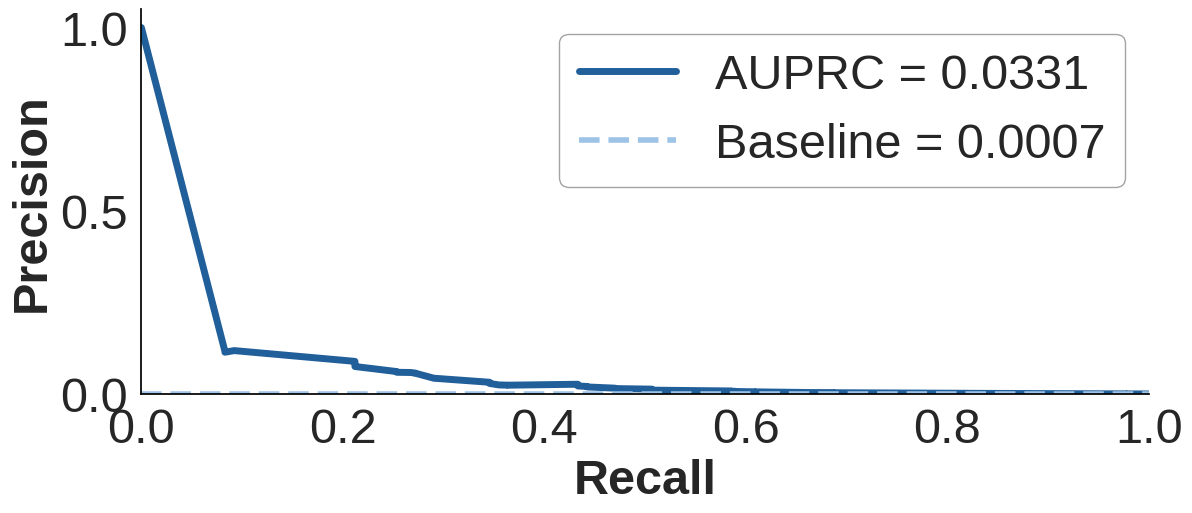

In [5]:
# Store the binary actual labels.
y_true = df["true_label"]

# Store the model prediction scores.
y_score = df["predicted_score"]

# Calculate precision, recall, and thresholds for the precision-recall curve.
precision, recall, thresholds = precision_recall_curve(y_true, y_score)

# Calculate average precision, commonly used as AUPRC.
auprc = average_precision_score(y_true, y_score)

# Calculate the baseline precision from the positive-class prevalence.
baseline_precision = y_true.mean()

# Create the figure and axis.
fig, ax = plt.subplots(figsize=(13, 5))

# Plot the precision-recall curve with a thick blue line.
ax.plot(
    recall,
    precision,
    color="#215F9A",
    linewidth=5,
    label=f"AUPRC = {auprc:.4f}"
)

# Plot the baseline precision with a lighter blue dashed line.
ax.axhline(
    baseline_precision,
    color="#9DC3E6",
    linewidth=4,
    linestyle="--",
    label=f"Baseline = {baseline_precision:.4f}"
)

# Set the chart title with 25-point font.
# ax.set_title("Precision-Recall Curve", fontsize=25)

# Set the x-axis title with 25-point font.
ax.set_xlabel("Recall", fontsize=35)

# Set the y-axis title with 25-point font.
ax.set_ylabel("Precision", fontsize=35)

# Set the x-axis range.
ax.set_xlim(0, 1)

# Set the y-axis lower bound.
ax.set_ylim(bottom=0)

# Set the x-axis tick text font size.
ax.tick_params(axis="x", labelsize=35)

# Set the y-axis tick text font size.
ax.tick_params(axis="y", labelsize=35)

# Add the legend after all labeled lines are plotted.
add_legend(ax)

# Save the chart as a high-resolution PNG.
plt.savefig("auprc_precision_recall_curve.png", dpi=300, bbox_inches="tight")

# Display the chart.
plt.show()

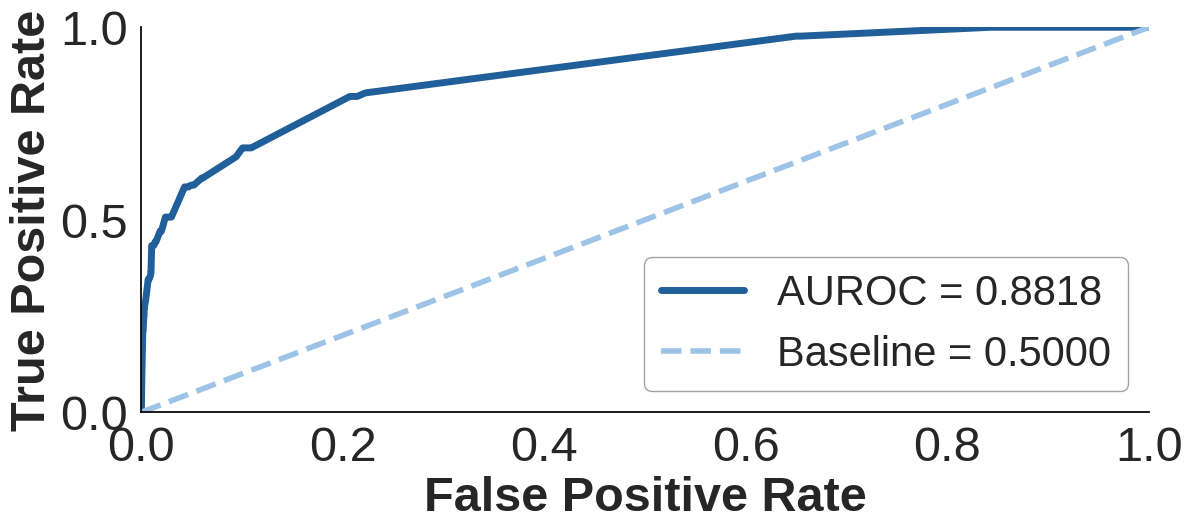

In [6]:
# Import AUROC metrics from scikit-learn.
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate false positive rate, true positive rate, and thresholds for the ROC curve.
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# Calculate area under the ROC curve.
auroc = roc_auc_score(y_true, y_score)

# Create the figure and axis.
fig, ax = plt.subplots(figsize=(13, 5))

# Plot the ROC curve with a thick blue line.
ax.plot(
    fpr,
    tpr,
    color="#215F9A",
    linewidth=5,
    label=f"AUROC = {auroc:.4f}"
)

# Plot the no-skill baseline with a lighter blue dashed line.
ax.plot(
    [0, 1],
    [0, 1],
    color="#9DC3E6",
    linewidth=4,
    linestyle="--",
    label="Baseline = 0.5000"
)

# Set the x-axis title with 35-point font.
ax.set_xlabel("False Positive Rate", fontsize=35)

# Set the y-axis title with 35-point font.
ax.set_ylabel("True Positive Rate", fontsize=35)

# Set the x-axis range.
ax.set_xlim(0, 1)

# Set the y-axis range.
ax.set_ylim(0, 1)

# Set the x-axis tick text font size.
ax.tick_params(axis="x", labelsize=35)

# Set the y-axis tick text font size.
ax.tick_params(axis="y", labelsize=35)

# Add the legend after all labeled lines are plotted.
add_legend(ax, loc="lower right", fontsize=30)

# Save the chart as a high-resolution PNG.
plt.savefig("auroc_roc_curve.png", dpi=300, bbox_inches="tight")

# Display the chart.
plt.show()